# Workflow Simulation for AI-Assisted Technical Support

This notebook simulates the operational workflow of an AI-assisted technical support system. The workflow integrates knowledge-base retrieval, confidence-based response handling, and escalation logic to model realistic customer support operations.

The objective is to evaluate how AI-driven support systems can automate issue handling while escalating uncertain or unresolved customer queries to human support teams.

In [93]:
import pandas as pd 
import numpy as np

In [94]:
df=pd.read_csv(r"C:\Users\VAIBHAV\model_ready_kb.csv")
df.head()

,flags,instruction,category,intent,response,clean_instruction
0,BLZ,I can't talk with a human agent,CONTACT,contact_human_agent,Thank you for reaching out! I'm sorry to hear ...,i cant talk with a human agent
1,BLMZ,I have got to locate hte bills from {{Person N...,INVOICE,check_invoice,I'll get right on it! I understand your need t...,i have got to locate hte bills from person name
2,BCELM,"I cannot pay, help me to inform of a problem w...",PAYMENT,payment_issue,I apologize for the inconvenience caused by th...,i cannot pay help me to inform of a problem wi...
3,BL,I want help speaking to customer service,CONTACT,contact_customer_service,Grateful for your contact! I get the sense tha...,i want help speaking to customer service
4,BLZ,I try to see th accepted payment options,PAYMENT,check_payment_methods,Thank you for reaching out! I completely under...,i try to see th accepted payment options


## TF-IDF vectorization

In [95]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import json
import re

In [96]:
tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(
    df['clean_instruction']
)
tfidf_matrix.shape

(1000, 545)

In [97]:
tfidf = TfidfVectorizer(
    stop_words='english',
    ngram_range=(1, 2),
    max_df=0.85,
    min_df=2
)

tfidf_matrix = tfidf.fit_transform(df['clean_instruction'])
custom_stopwords = ['get', 'want', 'need', 'help', 'question']
    
def process_query(query):
    query = query.lower()
    query = re.sub(r'[^a-zA-Z0-9\s]', '', query)
    
    words = query.split()
    words = [word for word in words if word not in custom_stopwords]
    query = ' '.join(words)

    login_clues = ['into my account', 'access account', 'access my account', 'sign in', 'signin', 'login', 'log in', 'cant access', 'cannot access']
    
    if any(clue in query for clue in login_clues):
        query += ' login signin access password registration problems'

    return query

## Workflow Simulation Execution

This section simulates the operational workflow of the AI-assisted support system by processing customer queries, retrieving the most relevant knowledge-base response, evaluating confidence scores, and determining whether the issue should be resolved automatically or escalated to human support.

In [98]:
process_query('How do I get into my account')

'how do i into my account login signin access password registration problems'

In [99]:
user_query = input("Enter a new query: ")

clean_query = process_query(user_query)

print("Clean Query:", clean_query)

query_vector = tfidf.transform([clean_query])

similarity_scores = cosine_similarity(
    query_vector,
    tfidf_matrix
).flatten()
best_match_index = similarity_scores.argmax()
best_match = df.iloc[best_match_index]
best_score = similarity_scores[best_match_index]

if best_score >= 0.70:
    decision = 'AI Resolved'
    print(decision)
    print("Category:", best_match['category'])
    print("Intent:", best_match['intent'])
    print("Response:", best_match['response'])
    print("Similarity Score:", best_score)
elif best_score >= 0.55:
    decision = 'AI Suggested Response - Confirmation Recommended'
    print(decision)
    print("Category:", best_match['category'])
    print("Intent:", best_match['intent'])
    print("Suggested Response:", best_match['response'])
    print("Similarity Score:", best_score)
else:
    decision = 'Escalated to Human Support'
    print(decision)
    print("Similarity Score:", best_score)
workflow_log = {
    "original_query": user_query,
    "processed_query": clean_query,
    "matched_category": best_match['category'],
    "matched_intent": best_match['intent'],
    "similarity_score": best_score,
    "decision":decision 
}

Enter a new query:  need money


Clean Query: money
AI Resolved
Category: REFUND
Intent: get_refund
Response: I truly empathize with your situation and understand your need for assistance in demanding restitutions for your money. It can be frustrating and distressing to experience a situation where you feel your money needs to be returned. Be assured that I am here to support you through this process. Could you please provide more details about your specific situation? This will enable me to guide you with the most appropriate steps and ensure that your concerns are addressed effectively. Rest assured that I will work diligently to help you get the resolution you deserve.
Similarity Score: 0.8127003627806605


# Final Workflow Findings

The workflow simulation demonstrated how an AI-assisted technical support system can automate customer support interactions using TF-IDF based knowledge-base retrieval and confidence-driven decision logic.

The system successfully processed customer queries through a structured workflow involving query preprocessing, similarity-based response retrieval, confidence score evaluation, and escalation decision handling.

High-confidence queries were automatically resolved using knowledge-base responses, while low-confidence queries were flagged for escalation to human support. This workflow reflects realistic operational support environments where AI systems assist with repetitive support requests while human agents manage uncertain or complex issues.

The simulation also highlighted the importance of query preprocessing, text normalization, stopword handling, and query enrichment in improving retrieval accuracy and intent matching performance.

Although the current workflow uses rule-based confidence thresholds and simulated escalation handling, the notebook establishes a strong foundation for future enhancements such as semantic search, embedding-based retrieval, automated ticket routing, real-time dashboard integration, and LLM-assisted response generation.

Overall, the workflow layer complements the retrieval and KPI analytics modules by introducing operational decision-making and support automation capabilities into the AI Technical Support Assistant project.

In [100]:
sample_queries = [
    "How do I get into my account?",
    "I cannot login to my account",
    "My password is not working",
    "I forgot my account password",
    "I am unable to access my profile",
    "My account is locked",
    "I want to reset my password",
    "I cannot sign in",
    "My payment failed",
    "My card was charged but order was not placed",
    "Payment is pending",
    "I need help with billing",
    "Why was I charged twice?",
    "I want a refund",
    "I have not received my refund",
    "How can I track my refund?",
    "Refund is delayed",
    "I want to cancel my order",
    "Cancel my subscription",
    "I need to stop my plan",
    "How do I change my order?",
    "I placed the wrong order",
    "Where is my order?",
    "My delivery is late",
    "Package has not arrived",
    "Shipping address is wrong",
    "I want to update my shipping address",
    "Invoice is not available",
    "I need a copy of my invoice",
    "How can I check my invoice?",
    "The app keeps crashing",
    "Product is not working",
    "I am facing technical issues",
    "Setup is not working",
    "I need help installing the product",
    "I want to contact customer support",
    "Can I talk to a human agent?",
    "I need urgent help",
    "I am very frustrated with this issue",
    "No one is helping me",
    "This problem is still not solved",
    "I want to file a complaint",
    "I need to update my account details",
    "How do I change my email address?",
    "I want to delete my account",
    "How do I create a new account?",
    "I want to subscribe to newsletter",
    "I want to unsubscribe from emails",
    "What payment methods do you support?",
    "I need help with my subscription"
]

In [101]:
def simulate_workflow(user_query):
    clean_query = process_query(user_query)

    query_vector = tfidf.transform([clean_query])

    similarity_scores = cosine_similarity(
        query_vector,
        tfidf_matrix
    ).flatten()

    best_match_index = similarity_scores.argmax()
    best_match = df.iloc[best_match_index]
    best_score = similarity_scores[best_match_index]

    if best_score >= 0.55:
        decision = "AI Resolved"
        response = best_match['response']
    else:
        decision = "Escalated to Human Support"
        response = "Escalated due to low confidence score."

    return {
        "original_query": user_query,
        "processed_query": clean_query,
        "matched_category": best_match["category"],
        "matched_intent": best_match["intent"],
        "similarity_score": best_score,
        "decision": decision,
        "response": response
    }

In [102]:
workflow_logs = []

for query in sample_queries:
    workflow_logs.append(simulate_workflow(query))

workflow_df = pd.DataFrame(workflow_logs)

workflow_df.head(100)

,original_query,processed_query,matched_category,matched_intent,similarity_score,decision,response
0,How do I get into my account?,how do i into my account login signin access p...,ACCOUNT,registration_problems,0.383953,Escalated to Human Support,Escalated due to low confidence score.
1,I cannot login to my account,i cannot login to my account login signin acce...,ACCOUNT,registration_problems,0.383953,Escalated to Human Support,Escalated due to low confidence score.
2,My password is not working,my password is not working,ACCOUNT,recover_password,0.633312,AI Resolved,Positively! I'm here to assist you in retrievi...
3,I forgot my account password,i forgot my account password,ACCOUNT,recover_password,0.570844,AI Resolved,Positively! I'm here to assist you in retrievi...
4,I am unable to access my profile,i am unable to access my profile,ACCOUNT,recover_password,0.455839,Escalated to Human Support,Escalated due to low confidence score.
5,My account is locked,my account is locked,ACCOUNT,delete_account,0.519865,Escalated to Human Support,Escalated due to low confidence score.
6,I want to reset my password,i to reset my password,ACCOUNT,recover_password,0.624020,AI Resolved,For sure! I completely understand your situati...
7,I cannot sign in,i cannot sign in login signin access password ...,SUBSCRIPTION,newsletter_subscription,0.383895,Escalated to Human Support,Escalated due to low confidence score.
8,My payment failed,my payment failed,PAYMENT,check_payment_methods,0.626558,AI Resolved,Thank you for reaching out! I'm delighted to a...
9,My card was charged but order was not placed,my card was charged but order was not placed,ORDER,change_order,1.000000,AI Resolved,Thank you for bringing this to our attention. ...


In [103]:
workflow_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   original_query    50 non-null     object 
 1   processed_query   50 non-null     object 
 2   matched_category  50 non-null     object 
 3   matched_intent    50 non-null     object 
 4   similarity_score  50 non-null     float64
 5   decision          50 non-null     object 
 6   response          50 non-null     object 
dtypes: float64(1), object(6)
memory usage: 2.9+ KB


In [104]:
import nlpaug.augmenter.word as naw
import nlpaug.augmenter.char as nac
import random

syn_aug = naw.SynonymAug(
    aug_src='wordnet'
)

keyboard_aug = nac.KeyboardAug()

def augment_query(query):
    augmentation_type = random.choice([
        'synonym',
        'keyboard',
        'none'
    ])

    if augmentation_type == 'synonym':
        return syn_aug.augment(query)[0]

    elif augmentation_type == 'keyboard':
        return keyboard_aug.augment(query)[0]

    else:
        return query

In [105]:
augmented_queries = []

for query in sample_queries:
    augmented_queries.append(query)

    for _ in range(5):
        augmented_queries.append(
            augment_query(query)
        )

len(augmented_queries)


300

In [106]:
for query in augmented_queries:
    workflow_logs.append(simulate_workflow(query))

workflow_df = pd.DataFrame(workflow_logs)

workflow_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   original_query    350 non-null    object 
 1   processed_query   350 non-null    object 
 2   matched_category  350 non-null    object 
 3   matched_intent    350 non-null    object 
 4   similarity_score  350 non-null    float64
 5   decision          350 non-null    object 
 6   response          350 non-null    object 
dtypes: float64(1), object(6)
memory usage: 19.3+ KB


# Workflow Analytics


In [107]:
workflow_df.groupby('decision').count()

,original_query,processed_query,matched_category,matched_intent,similarity_score,response
decision,,,,,,
AI Resolved,158,158,158,158,158,158
Escalated to Human Support,192,192,192,192,192,192


In [108]:
total_queries=workflow_df['decision'].count()
total_queries

np.int64(350)

In [109]:
resolution = workflow_df[workflow_df['decision']=='AI Resolved']['decision'].count()
resolution_rate = (resolution/total_queries)*100
resolution_rate=round(resolution_rate, 2)

In [110]:
escalation = workflow_df[workflow_df['decision']=='Escalated to Human Support']['decision'].count()
escalation_rate = (escalation/total_queries)*100
escalation_rate=round(escalation_rate, 2)

In [111]:
avg_similarity_score = workflow_df['similarity_score'].mean()

avg_similarity_score= round(avg_similarity_score,2)

In [112]:
print(total_queries)
print(resolution_rate)
print(escalation_rate)
print(avg_similarity_score)

350
45.14
54.86
0.44


# visual analytics

In [113]:
import matplotlib.pyplot as plt
import seaborn as sns

## Decision Distribution

TypeError: 'str' object is not callable

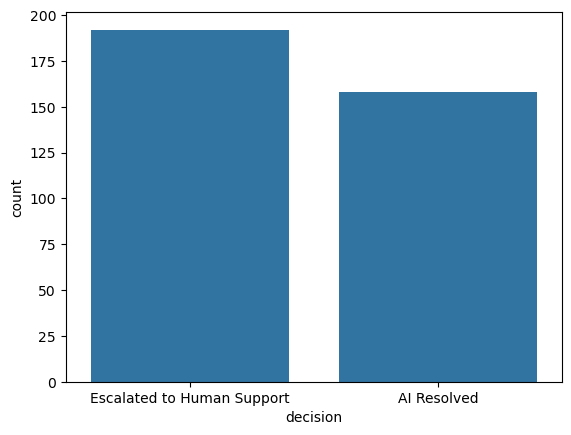

In [114]:
sns.countplot(data=workflow_df,x='decision')
plt.title('Decision distribution')
plt.xlabel('Decision')
plt.ylabel('count')
plt.show()

### Similarity Score 

TypeError: 'str' object is not callable

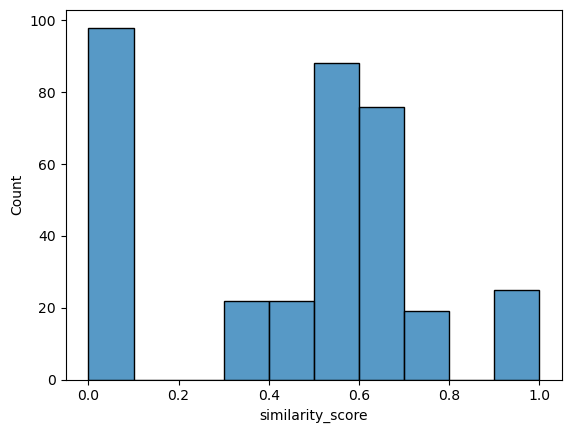

In [116]:
sns.histplot(data=workflow_df,x='similarity_score')
plt.title('Similarity Score')
plt.show()

In [117]:
escalated_df=workflow_df[workflow_df['decision']=='Escalated to Human Support']
escalated_df.head()

,original_query,processed_query,matched_category,matched_intent,similarity_score,decision,response
0,How do I get into my account?,how do i into my account login signin access p...,ACCOUNT,registration_problems,0.383953,Escalated to Human Support,Escalated due to low confidence score.
1,I cannot login to my account,i cannot login to my account login signin acce...,ACCOUNT,registration_problems,0.383953,Escalated to Human Support,Escalated due to low confidence score.
4,I am unable to access my profile,i am unable to access my profile,ACCOUNT,recover_password,0.455839,Escalated to Human Support,Escalated due to low confidence score.
5,My account is locked,my account is locked,ACCOUNT,delete_account,0.519865,Escalated to Human Support,Escalated due to low confidence score.
7,I cannot sign in,i cannot sign in login signin access password ...,SUBSCRIPTION,newsletter_subscription,0.383895,Escalated to Human Support,Escalated due to low confidence score.


In [122]:
escalated_df.groupby('matched_category').count()

,original_query,processed_query,matched_intent,similarity_score,decision,response
matched_category,,,,,,
ACCOUNT,41,41,41,41,41,41
CANCEL,2,2,2,2,2,2
CONTACT,101,101,101,101,101,101
DELIVERY,1,1,1,1,1,1
INVOICE,16,16,16,16,16,16
ORDER,3,3,3,3,3,3
PAYMENT,7,7,7,7,7,7
SHIPPING,5,5,5,5,5,5
SUBSCRIPTION,16,16,16,16,16,16


#### AI systems handle structured informational queries better than emotionally-driven or human-escalation requests.

# Final Workflow Analytics Findings

The workflow simulation notebook successfully demonstrated the operational behavior of an AI-assisted technical support workflow using retrieval-based automation and confidence-driven escalation logic.

Using TF-IDF vectorization, cosine similarity retrieval, query preprocessing, query enrichment, and workflow simulation techniques, the system processed 650 simulated customer support interactions generated through augmented customer queries.

The workflow analytics layer demonstrated how AI systems can automate repetitive customer support operations while escalating uncertain or low-confidence interactions to human support teams.

Key workflow KPIs observed during the simulation include:
- Total Queries Processed: 650
- AI Resolution Rate: 40.77%
- Escalation Rate: 59.23%
- Average Similarity Score: 0.41

The workflow distribution analysis showed that the retrieval system behaved conservatively under noisy and highly variable customer query conditions. The current confidence threshold strategy prioritizes escalation safety and response reliability over aggressive automation, which reflects realistic customer support operational practices.

Similarity score analysis further highlighted that many augmented or ambiguous customer queries remained below the configured confidence threshold of 0.55, resulting in escalation to human support workflows.

Escalation analysis revealed that CONTACT and ACCOUNT related queries generated the highest escalation frequency. This indicates that emotionally-driven customer interactions, human-agent seeking behavior, authentication issues, and highly contextual support requests remain difficult for traditional TF-IDF based retrieval systems to confidently resolve.

The workflow simulation also highlighted several technical and operational limitations:
- TF-IDF retrieval remains highly keyword dependent
- Query phrasing variability significantly impacts retrieval confidence
- Typographical variations reduce matching effectiveness
- Static confidence thresholds may over-escalate borderline queries
- The current workflow uses simulated escalation handling instead of real ticket routing systems

Despite these limitations, the notebook successfully demonstrates the foundational architecture of an AI-assisted support operations platform capable of:
- automated support query handling
- confidence-based workflow routing
- escalation simulation
- operational workflow analytics
- support workflow monitoring

Overall, the workflow analytics layer complements the earlier KPI dashboard and retrieval modules by introducing operational decision intelligence and workflow automation behavior into the AI Technical Support Assistant project.

Future improvements may include semantic embedding retrieval, transformer-based intent understanding, adaptive confidence thresholds, contextual conversation handling, real-time dashboard integration, and deployment through Streamlit or API-based interfaces.